/var/folders/sb/cwxtw9793kdbp3wnbtzhc9780000gn/T/ipykernel_99765/3606179992.py:57: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


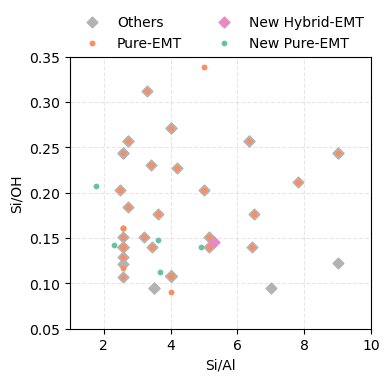

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

colors = sns.color_palette('Set2')


# === Load data ===
df1 = pd.read_excel('./Filtered_original_space.xlsx')
df2 = pd.read_excel('./New_data_1.xlsx')


# === Labeling and Styling ===
df1['LegendLabel'] = df1['EMT'].map({1: 'Pure-EMT', 0: 'Others'})


# df1['Color'] = df1['EMT'].map({1: '#1f77b4', 0: '#ff7f0e'})
df1['Color'] = df1['EMT'].map({1: colors[1], 0: colors[7]})
df1['Marker'] = df1['EMT'].map({1: 'o', 0: 'D'})  # circle for Pure-EMT, diamond for Others


df2['LegendLabel'] = df2['Results'].map({
    'EMT': 'New Pure-EMT',
    'EMT+impurities': 'New Hybrid-EMT'
})
# df2['Color'] = df2['Results'].map({'EMT': '#2ca02c', 'EMT+impurities': '#9467bd'})
df2['Color'] = df2['Results'].map({'EMT': colors[0], 'EMT+impurities': colors[3]})
df2['Marker'] = df2['Results'].map({'EMT': 'o', 'EMT+impurities': 'D'})

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# # === Font sizes ===
# font_sizes = {
#     'title': 25,
#     'axis_labels': 25,
#     'tick_labels': 25,
#     'legend': 25,
#     'legend_title': 25
# }

plt.style.use('default')

# === Square figure ===
fig, ax = plt.subplots(figsize=(4, 4))  # square figure

# === Plot each group separately ===
label_order = ['Others', 'Pure-EMT', 'New Hybrid-EMT', 'New Pure-EMT']
for label in label_order:
    sub = df[df['LegendLabel'] == label]
    
    # Bigger diamonds, normal circles
    marker_style = sub['Marker'].iloc[0]
    size = 30 if marker_style == 'D' else 10
    
    ax.scatter(
        sub['Si/Al'], sub['Si/OH'],
        s=size,
        marker=marker_style,
        c=sub['Color'].iloc[0],
        # edgecolor='black',
        # linewidth=1,
        label=label
    )


ax.legend(
    # handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),
    ncol=2,
    frameon=False,
     # fontsize=font_sizes['legend'],
    # title_fontsize=font_sizes['legend_title'],
    # handletextpad=0.03
)

# === Final Touches ===
ax.set_xlabel('Si/Al', #fontsize=font_sizes['axis_labels']
             )
ax.set_ylabel('Si/OH', #fontsize=font_sizes['axis_labels']
             )
ax.tick_params(axis='both', which='major', #labelsize=font_sizes['tick_labels']
              )
ax.grid(True, linestyle='--', alpha=0.3)

# # === Thicker box (spines) ===
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_edgecolor("black")

ax.set_xlim(1, 10.)
ax.set_ylim(0.05, 0.35)

plt.tight_layout()
plt.savefig('dist_two_feats_exp.pdf',  bbox_inches='tight', facecolor='white')
# plt.show()


In [2]:
import pandas as pd

# File path
file_path = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Finals.xlsx"

# Read Excel file
df = pd.read_excel(file_path)

# Number of original rows
n_rows = 38

# Create a copy of only the original rows
df_avg = df.iloc[0:n_rows].copy()

# Calculate averages for each corresponding group of 4 rows
avg_probability = []
avg_distance = []

for i in range(n_rows):

    # Get the 4 matching rows
    matching_rows = [
        i,
        i + n_rows,
        i + (2 * n_rows),
        i + (3 * n_rows)
    ]

    # Average Probability
    prob_mean = df.loc[matching_rows, 'Probability'].mean()

    # Average euclidean_distance
    dist_mean = df.loc[matching_rows, 'euclidean_distance'].mean()

    avg_probability.append(prob_mean)
    avg_distance.append(dist_mean)

# Replace columns with averaged values
df_avg['Probability'] = avg_probability
df_avg['euclidean_distance'] = avg_distance

# Save output
output_path = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Final_average.csv"

df_avg.to_csv(output_path, index=False)

print("Done!")
print(f"Averaged rows and saved file to:\n{output_path}")

Done!
Averaged rows and saved file to:
/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Final_average.csv


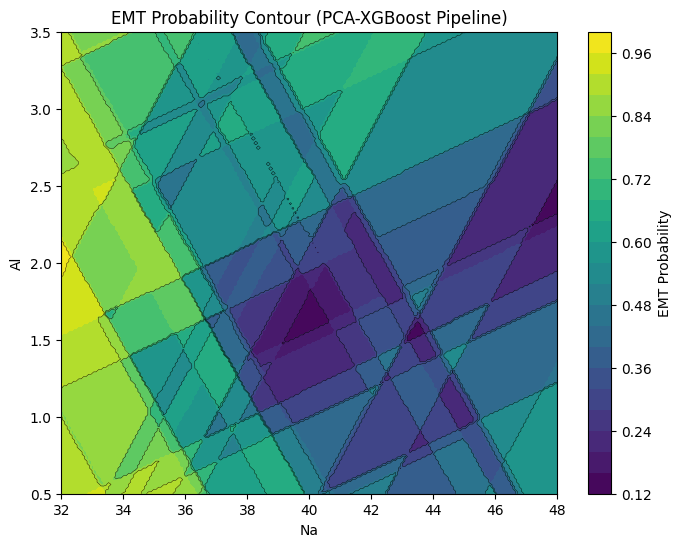

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# LOAD MODEL
# =========================
model = joblib.load('/Users/eolanrew/Desktop/Filtered_dataset/xgb_pca.pkl')

# =========================
# LOAD TRAINING DATA
# =========================
train_file = '/Users/eolanrew/Desktop/Filtered_dataset/Filtered_original_space.xlsx'
df = pd.read_excel(train_file)

# =========================
# FEATURE LIST
# =========================
columns_for_pca = [
    'Na', 'Al', 'Si', 'H2O',
    'Si_source_Fumed silica', 'Si_source_Ludox-AS40',
    'Si_source_Ludox-SM30', 'Si_source_Na2SiO3',
    'Si_source_TEOS', 'Pre-dissolution of Si',
    'Al_source_Al(OH)3', 'Al_source_NaAlO2',
    'Pre-dissolution of Al', 'Si/OH', 'Si/Al',
    'Time (h)', 'Temperature (°C)',
    'Si precursor sizs (nm)'
]

# =========================
# SCALER (same logic as training)
# =========================
exclude_from_scaling = [
    'Si_source_Fumed silica', 'Si_source_Ludox-AS40',
    'Si_source_Ludox-SM30', 'Si_source_Na2SiO3',
    'Si_source_TEOS', 'Pre-dissolution of Si',
    'Al_source_Al(OH)3', 'Al_source_NaAlO2',
    'Pre-dissolution of Al'
]

columns_to_scale = [
    c for c in columns_for_pca if c not in exclude_from_scaling
]

scaler = StandardScaler()
scaler.fit(df[columns_for_pca][columns_to_scale])

# =========================
# PCA FIT
# =========================
X_scaled = df[columns_for_pca].copy()
X_scaled[columns_to_scale] = scaler.transform(X_scaled[columns_to_scale])

pca = PCA(n_components=3)
pca.fit(X_scaled)

# =========================
# SELECT FEATURES (Si vs Na)
# =========================
f1, f2 = "Si", "Na"

base = df[columns_for_pca].mean()

# =========================
# STOICHIOMETRY
# =========================
def enforce_stoichiometry(row):
    row = row.copy()
    row["Si_Al"] = row["Si"] / row["Al"] if row["Al"] != 0 else 0
    row["Si_OH"] = row["Si"] / row["Na"] if row["Na"] != 0 else 0
    return row

# =========================
# GRID
# =========================
n_grid = 200

x_vals = np.linspace(df[f1].min(), df[f1].max(), n_grid)
y_vals = np.linspace(df[f2].min(), df[f2].max(), n_grid)

XX, YY = np.meshgrid(x_vals, y_vals)
Z = np.zeros_like(XX)

# =========================
# PREDICTION
# =========================
for i in range(n_grid):
    for j in range(n_grid):

        row = base.copy()

        row["Si"] = XX[i, j]
        row["Na"] = YY[i, j]

        row = enforce_stoichiometry(row)

        X = pd.DataFrame([row])[columns_for_pca]

        X_scaled = X.copy()
        X_scaled[columns_to_scale] = scaler.transform(X_scaled[columns_to_scale])

        X_pca = pca.transform(X_scaled)

        Z[i, j] = model.predict_proba(X_pca)[0, 1]

# =========================
# PLOT (MATCHING YOUR STYLE)
# =========================
plt.style.use('default')

fig, ax = plt.subplots(figsize=(4, 4))  # SAME AS YOUR SCATTER PLOT

cp = ax.contourf(XX, YY, Z, levels=20, cmap="viridis")
cbar = plt.colorbar(cp)
cbar.set_label('EMT Probability')

ax.contour(XX, YY, Z, levels=10, colors='black', linewidths=0.3)

# =========================
# LABELS (MATCH YOUR STYLE)
# =========================
ax.set_xlabel('Si')
ax.set_ylabel('Na')

ax.tick_params(axis='both', which='major')

ax.grid(True, linestyle='--', alpha=0.3)

# =========================
# LIMITS (optional adjust)
# =========================
ax.set_xlim(df["Si"].min(), df["Si"].max())
ax.set_ylim(df["Na"].min(), df["Na"].max())

plt.tight_layout()
plt.savefig('contour_Si_Na.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [3]:
import pandas as pd

file_path = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Final_average.csv"

df = pd.read_csv(file_path)

# create Model column based on Probability threshold
df["Model"] = (df["Probability"] >= 0.5).astype(int)

output_path = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Final_average_updated.csv"

df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/Corrected/EMT_Final_average_updated.csv


In [1]:
import pandas as pd

# ── UPDATE PATHS ─────────────────────────────────────────────────────────────
input_path   = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/corrected_1/EMT_Finals.xlsx"
output_step1 = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/corrected_1/EMT_Step1.xlsx"
output_step2 = "/Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/corrected_1/EMT_Step2.xlsx"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_excel(input_path)
print(f"Loaded: {df.shape}")  # (744, 26)

pred_cols        = ["Probability", "euclidean_distance"]
original_row_col = "Unnamed: 0"

# STEP 1: Average over categorical features, keep all other columns
step1 = (
    df.groupby([original_row_col, "Si precursor sizs (nm)"], sort=False)[pred_cols]
    .mean()
    .reset_index()
)
meta_cols_s1 = [c for c in df.columns if c not in pred_cols + ["Pre-dissolution of Al", "Pre-dissolution of Si"]]
meta_s1      = df.groupby([original_row_col, "Si precursor sizs (nm)"], sort=False)[meta_cols_s1].first().reset_index(drop=True)
step1_full   = pd.concat([meta_s1, step1[pred_cols]], axis=1)
print(f"After Step 1: {step1_full.shape}")  # expect (186, 24)
step1_full.to_excel(output_step1, index=False)
print(f"Saved → {output_step1}")

# STEP 2: Average over Si sizes, keep all other columns
step2 = (
    step1.groupby(original_row_col, sort=False)[pred_cols]
    .mean()
    .reset_index()
)
meta_cols_s2 = [c for c in df.columns if c not in pred_cols + ["Si precursor sizs (nm)", "Pre-dissolution of Al", "Pre-dissolution of Si"]]
meta_s2      = df.groupby(original_row_col, sort=False)[meta_cols_s2].first().reset_index(drop=True)
final_df     = pd.concat([meta_s2, step2[pred_cols]], axis=1)
print(f"After Step 2: {final_df.shape}")  # expect (31, 23)
final_df.to_excel(output_step2, index=False)
print(f"Saved → {output_step2}")

Loaded: (744, 26)
After Step 1: (186, 24)
Saved → /Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/corrected_1/EMT_Step1.xlsx
After Step 2: (31, 23)
Saved → /Users/eolanrew/Desktop/Qlearning/Inference/KV Cache/corrected_1/EMT_Step2.xlsx
